In [1]:
# ==============================================================================
# --- CELDA 1: IMPORTACIONES Y MÓDULOS ---
# ==============================================================================
import os
import numpy as np
import rasterio
import fiona
from datetime import datetime
from tqdm import tqdm
import time
import gc
import glob

# --- Adiciones para Paralelización, Monitoreo y Visualización ---
import threading
import psutil
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd
import geopandas as gpd
import rasterio.plot
from rasterio.windows import from_bounds
from shapely.geometry import box

# --- Importar los módulos personalizados del paquete lcp ---
import lcp.data_loader as dl
import lcp.processing as proc
import lcp.pathfinder as pf
import lcp.utils as utils
import lcp.postprocessing as postp 

print("Módulos cargados exitosamente.")

Módulos cargados exitosamente.


In [2]:
# ==============================================================================
# --- CELDA 2: DEFINICIÓN DE FUNCIONES ---
# ==============================================================================

def lcp_worker_one_to_all(args):
    """
    Worker para el cálculo 'Uno a Todos' en paralelo.
    1. Lee el ráster de coste desde un memmap compartido.
    2. Calcula la superficie de coste completa desde el origen con pf.cost_surface_calculator().
    3. Reconstruye todas las rutas y devuelve una lista de registros en memoria.
    """
    origin_id, origin_coords, all_points, shared_data = args

    try:
        cost_raster_in_memory = np.array(np.memmap(
            shared_data['memmap_path'],
            dtype=shared_data['raster_dtype'],
            mode='r',
            shape=shared_data['raster_shape']
        ))

        start_pixel = proc.world_to_pixel(
            shared_data['src_transform'], origin_coords[0], origin_coords[1]
        )

        costs_surface, traceback_arr = pf.cost_surface_calculator(cost_raster_in_memory, start_pixel)

        records = postp.extract_routes(
            traceback_arr, costs_surface, origin_id, origin_coords,
            all_points, shared_data['src_transform'], verbose=False
        )

        del cost_raster_in_memory, costs_surface, traceback_arr
        return (origin_id, records)

    except Exception as e:
        print(f"ERROR en el worker para el origen {origin_id}: {e}")
        import traceback as tb
        tb.print_exc()
        return (origin_id, [])


def resource_monitor(stop_event, records_list, interval=1):
    """
    Monitorea el uso de CPU y memoria en un hilo separado.
    """
    process = psutil.Process(os.getpid())
    while not stop_event.is_set():
        cpu = psutil.cpu_percent(interval=None)
        mem = sum(
            p.memory_info().rss for p in [process] + process.children(recursive=True)
        ) / (1024 * 1024)
        records_list.append({'cpu': cpu, 'mem_mb': mem})
        time.sleep(interval)


def warm_up_numba():
    """
    Pre-compila reconstruct_path_from_traceback con Numba JIT usando datos de prueba.
    Debe llamarse una vez antes del bucle principal para evitar la latencia de compilación.
    """
    print("Pre-compilando función Numba (warm-up)...")
    dummy_raster = np.ones((10, 10), dtype=np.float64)
    _, dummy_traceback = pf.cost_surface_calculator(dummy_raster, (5, 5))
    pf.reconstruct_path_from_traceback(dummy_traceback, (5, 5), (2, 2))
    print("Warm-up completado.")


In [3]:
# ==============================================================================
# --- CELDA 3: CONFIGURACIÓN CENTRAL DEL ANÁLISIS ---
# ==============================================================================
# --- 1. Parámetros de Rutas ---
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(R"G:\LCP-Rafa")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = os.path.join(BASE_DIR, 'output', f'session_{timestamp}_Refactored')

COST_RASTER_PATH = os.path.join(DATA_DIR, 'Coste_SN_corregido2.tif')
ALL_POINTS_SHAPEFILE = os.path.join(DATA_DIR, 'Sitios Vergel area estudio.gpkg')
MASK_SHAPEFILE_PATH = os.path.join(DATA_DIR, 'poligono utm cortado.shp')
ID_FIELD_NAME = 'fid'

# --- 2. Parámetros del Algoritmo Jerárquico ---
# Elige el método de remuestreo: 'max', 'med', 'average'
RESAMPLING_METHOD_NAME = 'max'
# Factores de remuestreo. Para un ráster de ~1000x1000, valores más pequeños son mejores.
DOWNSAMPLING_FACTORS = [32, 20, 10] 
CORRIDOR_BUFFER_PIXELS = 150

# --- 3. Parámetros de A* y Paralelización ---
HEURISTIC_WEIGHT = 1.0
N_JOBS = -2

# Verbosidad del análisis: True imprime detalles por ruta, False suprime el ruido.
VERBOSE = False

# Crear el directorio de salida inmediatamente después de definir su ruta.
# Esto asegura que estará disponible para todas las celdas posteriores (5, 6, 7).
try:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Directorio de salida creado/verificado en: {OUTPUT_DIR}")
except OSError as e:
    print(f"!! ERROR CRÍTICO !! No se pudo crear el directorio de salida. Error: {e}")
    # Detener la ejecución si no se puede crear la carpeta
    raise

print("Parámetros de configuración cargados. Los resultados se guardarán en:", OUTPUT_DIR)
print(f"Método de remuestreo seleccionado: {RESAMPLING_METHOD_NAME.upper()}")

Directorio de salida creado/verificado en: G:\LCP_MCP_Geometric\output\session_20260415_213517_Refactored
Parámetros de configuración cargados. Los resultados se guardarán en: G:\LCP_MCP_Geometric\output\session_20260415_213517_Refactored
Método de remuestreo seleccionado: MAX


In [4]:
# ==============================================================================
# --- CELDA 4: VERIFICACIÓN DE COHERENCIA DE DATOS ---
# ==============================================================================
print("\n--- VERIFICANDO LA COHERENCIA DE TODOS LOS DATOS DE ENTRADA ---")

main_search_mask = None  # Inicializar la variable para que esté disponible globalmente en la celda

try:
    # --- Etapa 1: Comprobación de Sistemas de Coordenadas (CRS) ---
    print("--- Etapa 1: Comprobación de Sistemas de Coordenadas (CRS) ---")
    
    with rasterio.open(COST_RASTER_PATH) as src:
        raster_crs = src.crs
    
    with fiona.open(ALL_POINTS_SHAPEFILE) as src:
        points_crs = src.crs

    print(f"  > CRS del Ráster: {raster_crs.to_string()}")
    print(f"  > CRS de los Puntos: {fiona.crs.to_string(points_crs)}")

    crs_errors = []
    if raster_crs != points_crs:
        crs_errors.append("El CRS de los PUNTOS no coincide con el del RÁSTER.")
    
    mask_crs = None
    if MASK_SHAPEFILE_PATH and os.path.exists(MASK_SHAPEFILE_PATH):
        with fiona.open(MASK_SHAPEFILE_PATH) as src:
            mask_crs = src.crs
        print(f"  > CRS de la Máscara: {fiona.crs.to_string(mask_crs)}")
        if raster_crs != mask_crs:
            crs_errors.append("El CRS de la MÁSCARA no coincide con el del RÁSTER.")
    
    if not crs_errors:
        print("¡Correcto! Todos los sistemas de coordenadas coinciden.")
    
    # --- Etapa 2: Comprobación de Superposición Espacial ---
    print("\n--- Etapa 2: Comprobación de Superposición Espacial ---")
    
    with rasterio.open(COST_RASTER_PATH) as src:
        raster_bounds = src.bounds
        raster_box = box(*raster_bounds)

    points_gdf = gpd.read_file(ALL_POINTS_SHAPEFILE)
    points_bounds = points_gdf.total_bounds
    points_box = box(*points_bounds)
    
    print(f"  > Extensión del Ráster: {raster_bounds}")
    print(f"  > Extensión de los Puntos: {tuple(points_bounds)}")

    superposition_errors = []
    if not points_box.within(raster_box):
        superposition_errors.append("La extensión de los PUNTOS no está completamente contenida dentro de la extensión del RÁSTER.")

    if MASK_SHAPEFILE_PATH and os.path.exists(MASK_SHAPEFILE_PATH):
        mask_gdf = gpd.read_file(MASK_SHAPEFILE_PATH)
        if not mask_gdf.empty:
            mask_bounds = mask_gdf.total_bounds
            mask_box = box(*mask_bounds)
            print(f"  > Extensión de la Máscara: {tuple(mask_bounds)}")
            if not mask_box.intersects(raster_box):
                superposition_errors.append("La extensión de la MÁSCARA no se superpone (intersecta) con la extensión del RÁSTER.")
    
    if not superposition_errors:
        print("¡Correcto! Todas las capas se superponen geográficamente.")

    # --- Etapa 3: Creación y Validación Lógica de la Máscara y Puntos ---
    print("\n--- Etapa 3: Creación y Validación Lógica Final (Máscara + Nodata + Puntos) ---")
    
    with rasterio.open(COST_RASTER_PATH) as src:
        # 3.1: Crear la máscara a partir del polígono vectorial
        if MASK_SHAPEFILE_PATH and os.path.exists(MASK_SHAPEFILE_PATH):
            vector_mask = proc.create_mask_from_vector(MASK_SHAPEFILE_PATH, src)
        else:
            print("  ADVERTENCIA: No se proporcionó un archivo de máscara. Se usará toda la extensión del ráster.")
            vector_mask = np.ones(src.shape, dtype=bool)

        # 3.2: Crear una máscara a partir de los valores 'nodata' del ráster
        original_cost_data = src.read(1)
        nodata_value = src.nodata
        if nodata_value is not None:
            nodata_mask = (original_cost_data == nodata_value)
            print(f"  > Se han detectado {np.sum(nodata_mask)} píxeles con valor 'nodata' en el ráster.")
        else:
            nodata_mask = np.zeros(src.shape, dtype=bool)
        
        # 3.3: Combinar ambas para obtener la máscara de búsqueda final y definitiva
        main_search_mask = vector_mask & ~nodata_mask
        
        # 3.4: Cargar los puntos y validarlos contra la MÁSCARA FINAL
        all_points_for_validation, _ = dl.load_points_as_dict(ALL_POINTS_SHAPEFILE, ID_FIELD_NAME)
        invalid_point_ids = []
        for point_id, coords in all_points_for_validation.items():
            row, col = rasterio.transform.rowcol(src.transform, coords[0], coords[1])
            if not (0 <= row < src.height and 0 <= col < src.width) or not main_search_mask[row, col]:
                invalid_point_ids.append(str(point_id))

        if not invalid_point_ids:
            print("¡Correcto! Todos los puntos están dentro del área de búsqueda válida final.")
    
    # --- Etapa 4: Veredicto Final ---
    final_errors = crs_errors + superposition_errors
    
    if invalid_point_ids:
        error_message_points = (
            f"Se encontraron {len(invalid_point_ids)} puntos que caen sobre píxeles INVÁLIDOS. "
            f"Un píxel es inválido si está fuera del polígono de la máscara O si tiene un valor 'nodata' en el ráster de coste. "
            f"(IDs de muestra: {', '.join(invalid_point_ids[:10])}{'...' if len(invalid_point_ids) > 10 else ''})."
        )
        final_errors.append(error_message_points)

    if final_errors:
        error_details = "\n- ".join(final_errors)
        error_message = (
            f"\n{'='*70}\n"
            f"!! ERROR CRÍTICO DE VALIDACIÓN DE DATOS !!\n"
            f"Se encontraron las siguientes inconsistencias:\n- {error_details}\n\n"
            f"El análisis no puede continuar. Debes corregir tus datos de entrada. Comprueba la posición de los puntos inválidos respecto a las áreas 'nodata' en tu software GIS.\n"
            f"{'='*70}"
        )
        raise ValueError(error_message)
    else:
        print("\n¡Excelente! Todos los datos de entrada son coherentes y están listos para el análisis.")

except Exception as e:
    print(f"Ocurrió un error inesperado durante la validación de datos: {e}")
    raise


--- VERIFICANDO LA COHERENCIA DE TODOS LOS DATOS DE ENTRADA ---
--- Etapa 1: Comprobación de Sistemas de Coordenadas (CRS) ---


  > CRS del Ráster: EPSG:32718


  > CRS de los Puntos: EPSG:32718
  > CRS de la Máscara: EPSG:32718
¡Correcto! Todos los sistemas de coordenadas coinciden.

--- Etapa 2: Comprobación de Superposición Espacial ---


  > Extensión del Ráster: BoundingBox(left=628308.40412, bottom=5741262.52115, right=653104.95844, top=5780480.97948)
  > Extensión de los Puntos: (np.float64(630223.0), np.float64(5747753.0), np.float64(649787.0), np.float64(5777318.0))
  > Extensión de la Máscara: (np.float64(628423.4416341122), np.float64(5741575.838881624), np.float64(653116.9545482149), np.float64(5780081.816311585))
¡Correcto! Todas las capas se superponen geográficamente.

--- Etapa 3: Creación y Validación Lógica Final (Máscara + Nodata + Puntos) ---
Creando máscara booleana desde el polígono (con limpieza de geometría)...
Máscara creada exitosamente.
  > Se han detectado 216478 píxeles con valor 'nodata' en el ráster.
Cargando puntos desde: Sitios Vergel area estudio.gpkg
  ADVERTENCIA: Campo 'fid' no encontrado en propiedades. Se usará el 'feature.id' (fid del GeoPackage).
Se cargaron 78 puntos.
¡Correcto! Todos los puntos están dentro del área de búsqueda válida final.

¡Excelente! Todos los datos de entrada


Iniciando visualización diagnóstica del ráster de coste y puntos...



Visualización diagnóstica guardada en: G:\LCP_MCP_Geometric\output\session_20260415_213517_Refactored\visualizacion_diagnostica.png


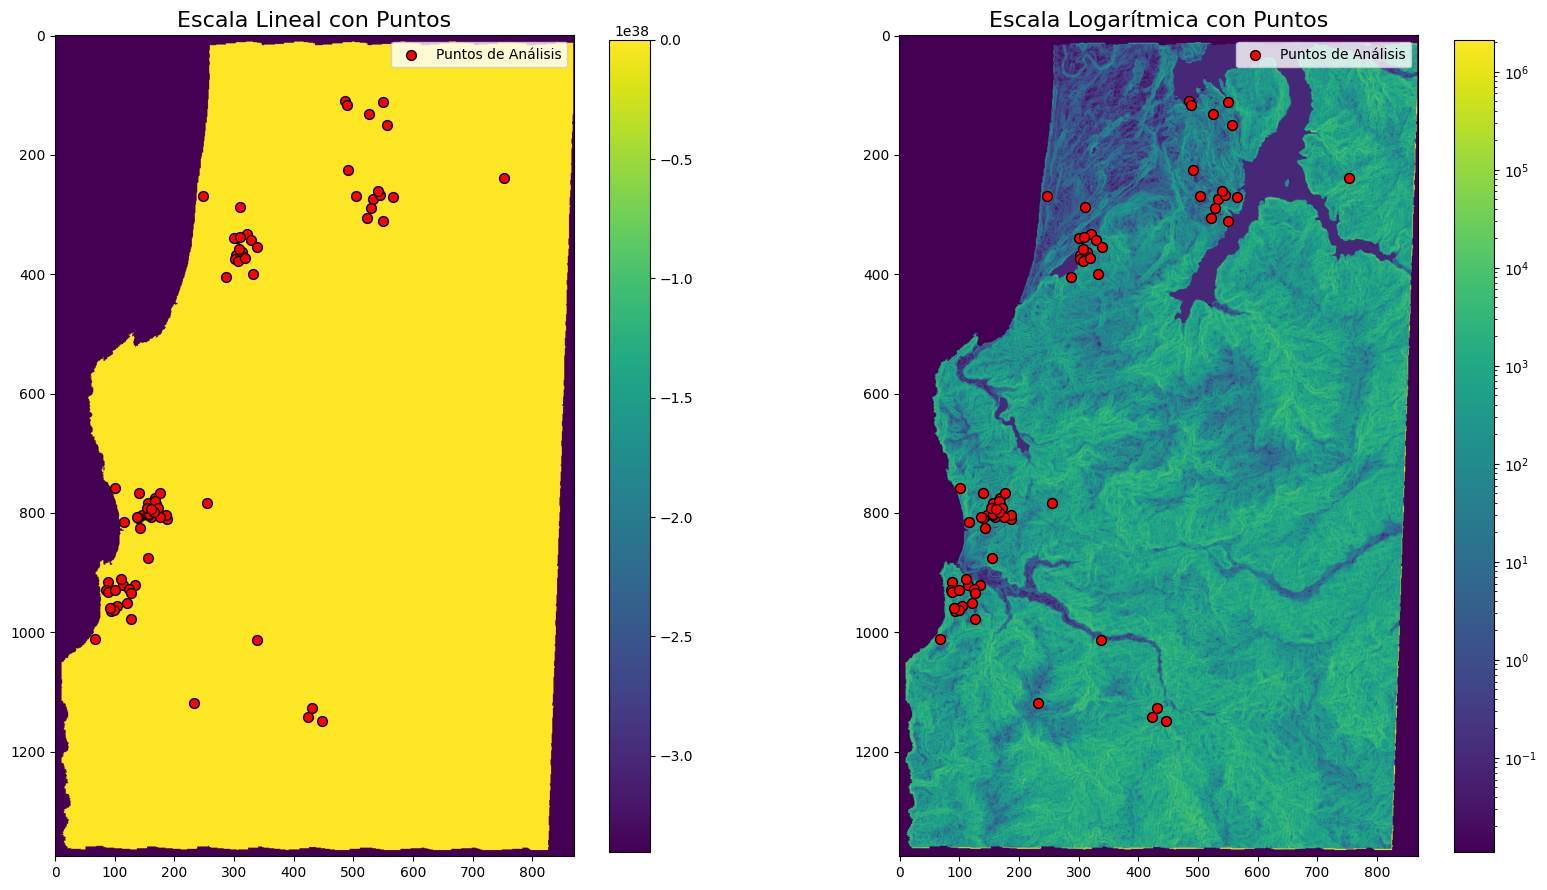

In [5]:
# ==============================================================================
# --- CELDA 5: VISUALIZACIÓN DIAGNÓSTICA (CON EXPORTACIÓN) ---
# ==============================================================================
print("\nIniciando visualización diagnóstica del ráster de coste y puntos...")
try:
    # Cargar el ráster de coste para obtener sus datos y metadatos
    with rasterio.open(COST_RASTER_PATH) as src:
        cost_data = src.read(1)
        transform = src.transform  # Guardar la transformación para convertir coordenadas

        # Preparar datos para la escala logarítmica, manejando valores no positivos
        min_pos_val = np.min(cost_data[cost_data > 0]) if np.any(cost_data > 0) else 1e-9
        cost_data_log = np.where(cost_data <= 0, min_pos_val, cost_data)

        # Cargar los puntos usando geopandas
        points_gdf = gpd.read_file(ALL_POINTS_SHAPEFILE)
        
        # Convertir las coordenadas geográficas de los puntos a coordenadas de píxel
        point_pixels_x = []
        point_pixels_y = []
        for point in points_gdf.geometry:
            # Usar rasterio.transform.rowcol para obtener fila y columna
            row, col = rasterio.transform.rowcol(transform, point.x, point.y)
            point_pixels_x.append(col)
            point_pixels_y.append(row)

        # Crear la figura y los ejes para los dos subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))

        # --- Subplot 1: Visualización con Escala Lineal ---
        im1 = ax1.imshow(cost_data, cmap='viridis')
        fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
        ax1.set_title('Escala Lineal con Puntos', fontsize=16)
        ax1.scatter(point_pixels_x, point_pixels_y, c='red', edgecolor='black', s=50, label='Puntos de Análisis', zorder=5)
        ax1.legend()

        # --- Subplot 2: Visualización con Escala Logarítmica ---
        im2 = ax2.imshow(cost_data_log, cmap='viridis', norm=LogNorm())
        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
        ax2.set_title('Escala Logarítmica con Puntos', fontsize=16)
        ax2.scatter(point_pixels_x, point_pixels_y, c='red', edgecolor='black', s=50, label='Puntos de Análisis', zorder=5)
        ax2.legend()

        # Ajustes finales
        plt.tight_layout()

        # --- INICIO DE LA MODIFICACIÓN: EXPORTACIÓN DE LA IMAGEN ---
        # Guardar la figura en el directorio de salida antes de mostrarla
        output_image_path = os.path.join(OUTPUT_DIR, 'visualizacion_diagnostica.png')
        # Usamos dpi=150 para una buena resolución y bbox_inches='tight' para eliminar bordes blancos
        fig.savefig(output_image_path, dpi=150, bbox_inches='tight')
        print(f"\nVisualización diagnóstica guardada en: {output_image_path}")
        # --- FIN DE LA MODIFICACIÓN ---

        # Mostrar el gráfico en la pantalla
        plt.show()

except FileNotFoundError as e:
    print(f"ADVERTENCIA: No se encontró un archivo necesario para la visualización: {e}. Saltando visualización.")
except Exception as e:
    print(f"Ocurrió un error durante la visualización: {e}")
    import traceback
    traceback.print_exc()

In [6]:
# ==============================================================================
# --- CELDA 6: EJECUCIÓN EN MODO PARALELO (JOBLIB + MEMMAP) ---
# ==============================================================================
print("\n--- INICIANDO PROCESO DE ANÁLISIS EN MODO PARALELO ---\n")
os.makedirs(OUTPUT_DIR, exist_ok=True)
all_route_records = []
memmap_path = os.path.join(OUTPUT_DIR, '_raster_shared.dat')

try:
    # 1. Preparar todos los datos en memoria una sola vez
    print("[Paso 1/4] Preparando todos los datos en memoria...")
    all_points, points_crs = dl.load_points_as_dict(ALL_POINTS_SHAPEFILE, ID_FIELD_NAME)
    max_id = max(all_points)

    with dl.load_raster(COST_RASTER_PATH) as src:
        transform = src.transform
        original_cost_data = src.read(1)
        # Cast a float64 UNA SOLA VEZ aqui, antes del bucle/workers
        final_cost_raster = np.where(main_search_mask, original_cost_data, np.inf).astype(np.float64)
        raster_shape = final_cost_raster.shape
        raster_dtype = final_cost_raster.dtype
        del original_cost_data

    print(
        f"[Paso 1/4] Datos preparados. "
        f"Forma del raster: {raster_shape}, Dtype: {raster_dtype}."
    )

    # 2. Escribir el raster en un archivo memmap compartido en disco
    print("[Paso 2/4] Escribiendo raster en memmap compartido...")
    mm = np.memmap(memmap_path, dtype=raster_dtype, mode='w+', shape=raster_shape)
    mm[:] = final_cost_raster[:]
    mm.flush()
    del mm, final_cost_raster
    print(f"[Paso 2/4] Memmap escrito en: {memmap_path}")

    shared_data = {
        'memmap_path':   memmap_path,
        'raster_dtype':  raster_dtype,
        'raster_shape':  raster_shape,
        'src_transform': transform,
    }

    # Calentar la funcion Numba antes de lanzar los workers
    warm_up_numba()

    # 3. Ejecutar el analisis en paralelo con joblib
    print(f"\n[Paso 3/4] Lanzando {N_JOBS} workers con joblib (backend=loky)...")
    start_time = time.time()

    tasks = [
        (origin_id, origin_coords, all_points, shared_data)
        for origin_id, origin_coords in all_points.items()
        if origin_id < max_id
    ]
    print(f"  Total de origenes a procesar: {len(tasks)}")

    results = Parallel(n_jobs=N_JOBS, backend='loky', verbose=5)(
        delayed(lcp_worker_one_to_all)(args) for args in tasks
    )

    for origin_id, records in results:
        all_route_records.extend(records)

    total_duration = time.time() - start_time
    print("\n[Paso 3/4] Bucle paralelo completado.")

    # 4. Construir GeoDataFrame y escribir un unico GeoPackage
    print("\n[Paso 4/4] Escribiendo GeoPackage unificado...")
    routes_gdf = gpd.GeoDataFrame(all_route_records, crs=points_crs)
    gpkg_output_path = os.path.join(OUTPUT_DIR, 'red_completa_unificada.gpkg')
    routes_gdf.to_file(gpkg_output_path, driver='GPKG', layer='rutas_unificadas')
    print(f"[Paso 4/4] {len(routes_gdf)} rutas guardadas en: {gpkg_output_path}")

    print("\n" + "="*50)
    print("--- RESUMEN DE EJECUCION (MODO PARALELO) ---")
    print(f"Proceso completado en {total_duration:.2f} segundos.")
    print(f"Total de rutas calculadas: {len(routes_gdf)}.")
    print(f"Workers utilizados: N_JOBS={N_JOBS}")
    print("="*50)

except Exception as e:
    print(f"\nOcurrio un error fatal durante la ejecucion: {e}")
    import traceback as tb
    tb.print_exc()

finally:
    # Limpiar el archivo memmap temporal
    if os.path.exists(memmap_path):
        try:
            os.remove(memmap_path)
            print(f"\nMemmap temporal eliminado: {memmap_path}")
        except OSError as e:
            print(f"ADVERTENCIA: No se pudo eliminar el memmap temporal: {e}")
    print("\n--- ANALISIS COMPLETADO ---")



--- INICIANDO PROCESO DE ANÁLISIS EN MODO PARALELO ---

[Paso 1/4] Preparando todos los datos en memoria...
Cargando puntos desde: Sitios Vergel area estudio.gpkg
  ADVERTENCIA: Campo 'fid' no encontrado en propiedades. Se usará el 'feature.id' (fid del GeoPackage).
Se cargaron 78 puntos.
Cargando raster desde: Coste_SN_corregido2.tif
[Paso 1/4] Datos preparados. Forma del raster: (1376, 870), Dtype: float64.
[Paso 2/4] Escribiendo raster en memmap compartido...
[Paso 2/4] Memmap escrito en: G:\LCP_MCP_Geometric\output\session_20260415_213517_Refactored\_raster_shared.dat
Pre-compilando función Numba (warm-up)...


Warm-up completado.

[Paso 3/4] Lanzando -2 workers con joblib (backend=loky)...
  Total de origenes a procesar: 77


[Parallel(n_jobs=-2)]: Using backend LokyBackend with 15 concurrent workers.


[Parallel(n_jobs=-2)]: Done  42 tasks      | elapsed:   10.9s


[Parallel(n_jobs=-2)]: Done  64 out of  77 | elapsed:   13.1s remaining:    2.6s


[Parallel(n_jobs=-2)]: Done  77 out of  77 | elapsed:   13.5s finished



[Paso 3/4] Bucle paralelo completado.

[Paso 4/4] Escribiendo GeoPackage unificado...


[Paso 4/4] 3003 rutas guardadas en: G:\LCP_MCP_Geometric\output\session_20260415_213517_Refactored\red_completa_unificada.gpkg

--- RESUMEN DE EJECUCION (MODO PARALELO) ---
Proceso completado en 13.57 segundos.
Total de rutas calculadas: 3003.
Workers utilizados: N_JOBS=-2

Memmap temporal eliminado: G:\LCP_MCP_Geometric\output\session_20260415_213517_Refactored\_raster_shared.dat

--- ANALISIS COMPLETADO ---



Iniciando la visualización final de la red de rutas...
Visualizando 3003 rutas.



Visualización final guardada en: G:\LCP_MCP_Geometric\output\session_20260415_213517_Refactored\red_de_rutas_final.png


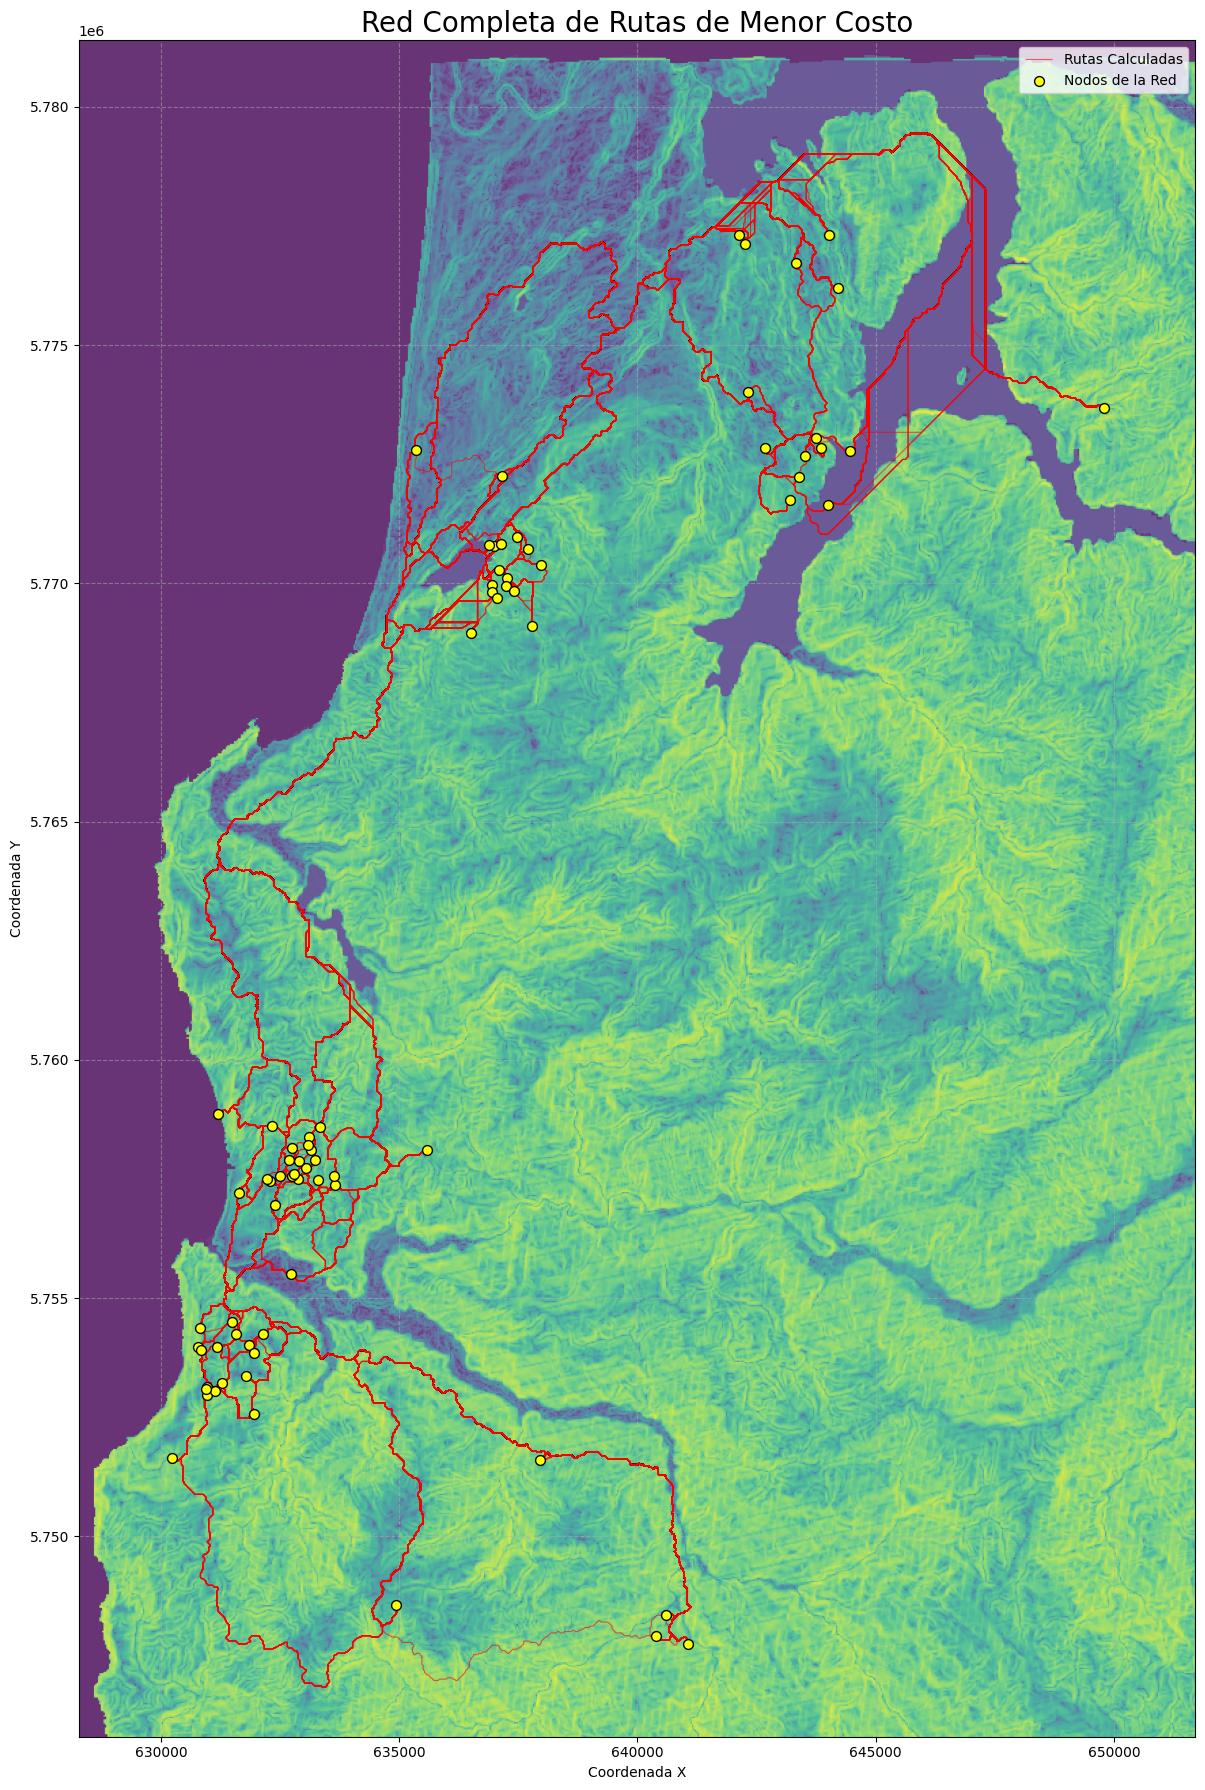

In [7]:
# ==============================================================================
# --- CELDA 7: VISUALIZACIÓN Y EXPORTACIÓN FINAL DE RESULTADOS ---
# ==============================================================================
print("\nIniciando la visualización final de la red de rutas...")

try:
    # Usar el GeoDataFrame construido en memoria por la Celda 6.
    # Si por alguna razón no existe (e.g. se ejecuta esta celda de forma aislada),
    # se carga desde el GeoPackage guardado.
    if 'routes_gdf' not in dir() or routes_gdf is None or len(routes_gdf) == 0:
        print("routes_gdf no disponible en memoria; cargando desde el GeoPackage...")
        routes_gdf = gpd.read_file(
            os.path.join(OUTPUT_DIR, 'red_completa_unificada.gpkg'),
            layer='rutas_unificadas'
        )

    final_routes_gdf = routes_gdf

    if len(final_routes_gdf) == 0:
        print("No hay rutas para visualizar.")
    else:
        print(f"Visualizando {len(final_routes_gdf)} rutas.")

        # 1. Determinar la extensión geográfica total
        minx, miny, maxx, maxy = final_routes_gdf.total_bounds
        margin = (maxx - minx) * 0.1
        buffered_bounds = (minx - margin, miny - margin, maxx + margin, maxy + margin)

        # 2. Cargar la porción del ráster de coste
        with rasterio.open(COST_RASTER_PATH) as src:
            window = from_bounds(*buffered_bounds, transform=src.transform)
            raster_data = src.read(1, window=window)
            window_transform = src.window_transform(window)

        # 3. Cargar los puntos originales
        points_gdf = gpd.read_file(ALL_POINTS_SHAPEFILE)

        # 4. Crear el mapa
        fig, ax = plt.subplots(figsize=(18, 18))

        min_pos_val = np.min(raster_data[raster_data > 0]) if np.any(raster_data > 0) else 1e-9
        raster_data_log = np.where(raster_data <= 0, min_pos_val, raster_data)
        rasterio.plot.show(raster_data_log, transform=window_transform, ax=ax, cmap='viridis', norm=LogNorm(), alpha=0.8)

        final_routes_gdf.plot(ax=ax, edgecolor='red', linewidth=0.8, label='Rutas Calculadas', alpha=0.6, zorder=3)
        points_gdf.plot(ax=ax, color='yellow', markersize=50, ec='black', label='Nodos de la Red', zorder=5)

        # 5. Configuración final del mapa
        ax.set_title('Red Completa de Rutas de Menor Costo', fontsize=20)
        ax.set_xlabel("Coordenada X"); ax.set_ylabel("Coordenada Y")
        ax.legend(); plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()

        output_image_path = os.path.join(OUTPUT_DIR, 'red_de_rutas_final.png')
        fig.savefig(output_image_path, dpi=300, bbox_inches='tight')
        print(f"\nVisualización final guardada en: {output_image_path}")

        plt.show()

except Exception as e:
    print(f"Ocurrió un error durante la visualización: {e}")
    import traceback as tb
    tb.print_exc()
